# Ecommerce Customer Segmentation And Prediction

## Objectives:
1. Enhance marketing strategies and customer retention by identifying distinct customer segments.
2. Use machine learning to segment customers and predict future purchase activity


## Read and Preprocess Data

In [1]:
import pandas as pd
import numpy as np

In [2]:
sales_data = pd.read_csv('data/data.csv', encoding='latin-1')
sales_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [3]:
sales_data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


## Data Preprocessing

### Check Null Values

In [4]:
sales_data.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
customerID_missing_percentage = sales_data.CustomerID.isna().sum() / len(sales_data) * 100
print(f"Missing data percentage (for customerID): {customerID_missing_percentage:.2f}%")

Missing data percentage (for customerID): 24.93%


In [6]:
sales_data.Country.value_counts()

Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


Records which have no Customer ID and no Description are likely to be zero-spend null records.

In [7]:
def describe_description_customer_nulls(df, target_cols):

    # Count nulls and flag rows missing both Description and CustomerID.
    missing_counts = df[target_cols].isna().sum()
    for col, count in missing_counts.items():
        print(f"{col} null records: {count}")

    null_records_mask = df[target_cols].isna().all(axis=1)
    common_zerovalue_records = df[null_records_mask]
    print(f"Records with both Description and CustomerID null: {len(common_zerovalue_records)}")

    
    cleaned_df = df[~null_records_mask].copy()
    print("Deleted zero-spend null records")
    return common_zerovalue_records, cleaned_df


In [8]:
_  , cleaned_df = describe_description_customer_nulls(sales_data, ["Description", "CustomerID"])

Description null records: 1454
CustomerID null records: 135080
Records with both Description and CustomerID null: 1454
Deleted zero-spend null records


In [9]:
cleaned_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [10]:
cleaned_df.isna().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64

Map CustomerID with InvoiceNo to identify how many customers have **multiple transactions** and better understand customer *spending patterns*.

In [11]:
def classify_customer_orders(df: pd.DataFrame):
    """Classify customers based on number of unique invoices."""
    
    customer_invoice_counts = (
        df.groupby("CustomerID")["InvoiceNo"]
          .nunique()
          .reset_index(name="invoice_count")
    )
    
    customer_invoice_counts["invoice_per_customer"] = customer_invoice_counts["invoice_count"].apply(
        lambda x: "single_invoice" if x == 1 else "multiple_invoices"
    )
    
    return customer_invoice_counts

In [12]:
customer_invoice_map_df = classify_customer_orders(cleaned_df)
customer_invoice_map_df.invoice_per_customer.value_counts()

invoice_per_customer
multiple_invoices    3059
single_invoice       1313
Name: count, dtype: int64

This means a lot of customers have multiple invoices associated with them than a one-to-one relationship.

In [13]:
customer_missing_mask = cleaned_df.CustomerID.isna()
customer_missing_df = cleaned_df[customer_missing_mask].copy()
customer_missing_df.to_csv('data/unknown_customer_data.csv',sep=',')

In [14]:
cleaned_df['CustomerID'] = cleaned_df.CustomerID.fillna(0).astype('Int64')

Fill na values in the 'CustomerID' column with 0 and convert the column to integer type for easier analysis.

In [15]:
cleaned_df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [16]:
print("Number of unique customers :", len(list(cleaned_df.CustomerID.value_counts())))

Number of unique customers : 4373


In [17]:
print("Number of total countries :", len(list(cleaned_df.Country.value_counts())))

Number of total countries : 38


In [18]:
print("Number of missing unit prices :", cleaned_df.UnitPrice.eq(0.0).sum())

Number of missing unit prices : 1061


In [19]:
free_items_df= cleaned_df[cleaned_df.UnitPrice.eq(0.0)]
free_items_df.to_csv("data/free_items.csv", sep=',')

In [20]:
cleaned_df["IsPromotion"] = (cleaned_df["UnitPrice"] == 0.0).astype(int)
cleaned_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsPromotion
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom,0
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom,0
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680,France,0
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680,France,0
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680,France,0
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680,France,0


In [21]:
cleaned_df["IsPromotion"].value_counts()

IsPromotion
0    539394
1      1061
Name: count, dtype: int64

## Feature Engineering

1. Clean the 'InvoiceDate' column and convert it to datetime format.
2. Add a 'TotalAmount' column which will contain total amount for each product (Quantity * UnitPrice).
3. Add RFM features:
   - **Recency**: Number of days since the last purchase.
        - How fresh is the transaction
   - **Frequency**: Total number of transactions.
        - How often do they purchase
   - **Monetary**: Total amount spent by the customer.
        - How much value do they bring

In [22]:
cleaned_df["InvoiceDate"] = pd.to_datetime(cleaned_df["InvoiceDate"])
cleaned_df["TotalAmount"] = cleaned_df["Quantity"] * cleaned_df["UnitPrice"]

In [23]:
def aggregate_rfm_data(df: pd.DataFrame):
    snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

    #Remove promotions from RFM data to avoid non-revenue generating items
    cleaned_no_promo_df = df[df.UnitPrice > 0]

    rfm = cleaned_no_promo_df.groupby("CustomerID").agg({
        "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
        "InvoiceNo": "nunique",
        "TotalAmount": "sum"
    }).reset_index()

    rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

    rfm = rfm[rfm["Monetary"] > 0]

    rfm['AvgOrderValue']  = (rfm['Monetary'] / rfm['Frequency'])

    return rfm

In [24]:
rfm_data = aggregate_rfm_data(cleaned_df)
rfm_data

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue
0,0,1,1610,1469806.24,912.923130
2,12347,2,7,4310.00,615.714286
3,12348,75,4,1797.24,449.310000
4,12349,19,1,1757.55,1757.550000
5,12350,310,1,334.40,334.400000
...,...,...,...,...,...
4367,18280,278,1,180.60,180.600000
4368,18281,181,1,80.82,80.820000
4369,18282,8,3,176.60,58.866667
4370,18283,4,16,2094.88,130.930000


### Exploratory Data Analysis (EDA)

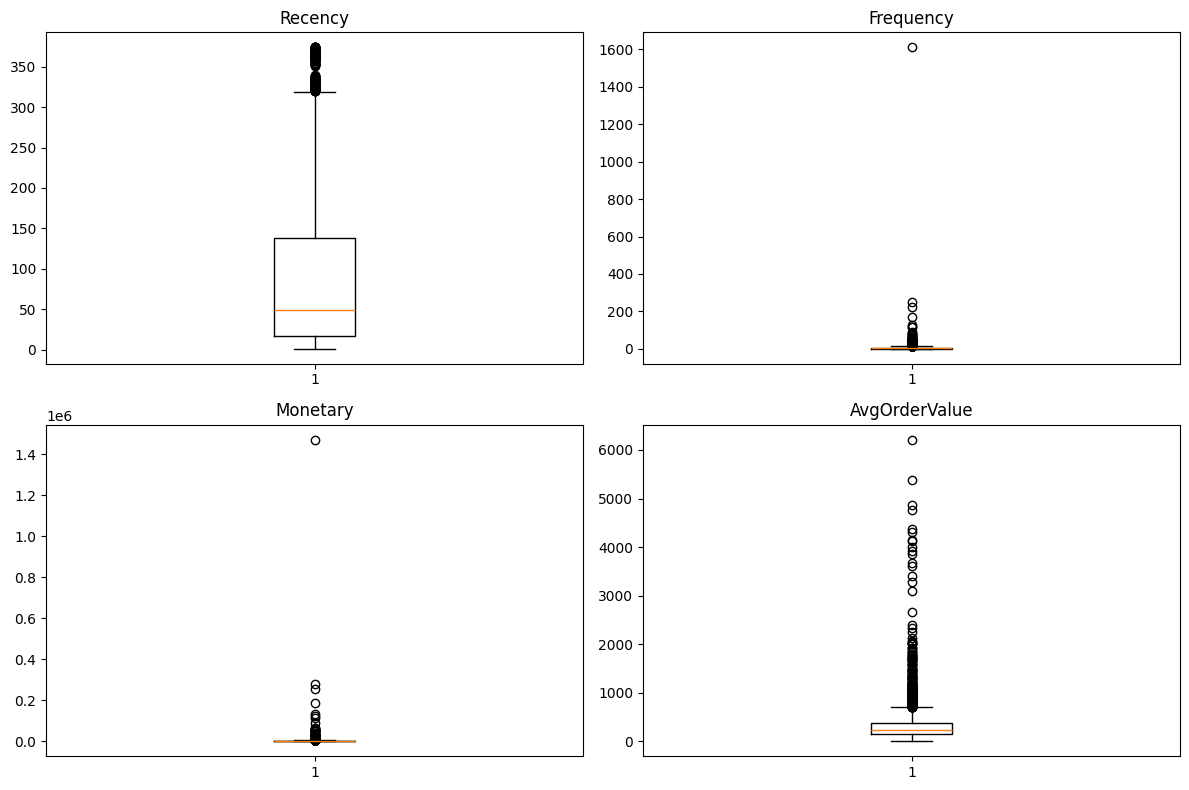

In [25]:
import matplotlib.pyplot as plt
import seaborn as sb

plt.figure(figsize=(12, 8))

for i, feature in enumerate(["Recency", "Frequency", "Monetary", "AvgOrderValue"], 1):
    plt.subplot(2, 2, i)
    plt.boxplot(rfm_data[feature])
    plt.title(feature)

plt.tight_layout()
plt.yscale('linear')
plt.show()

## Normalization and Scaling
Perform transformation for Monetary feature to reduce distribution skewness.

**Why?**

A few customers spend massively more than others. This can skew the clustering results, as K-Means is sensitive to outliers. By applying a log transformation, we can reduce the impact of these high-spending customers and create more balanced clusters.

In [26]:
from sklearn.preprocessing import RobustScaler, PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
features = rfm_data.columns.difference(['CustomerID'], sort=False)

def normalize_rfm(rfm): 
    print(rfm.describe())

    rfm["Recency"] = rfm["Recency"].clip(upper=rfm["Recency"].quantile(0.99))
    rfm["Monetary"] = rfm["Monetary"].clip(upper=rfm["Monetary"].quantile(0.99))
    rfm["Frequency"] = rfm["Frequency"].clip(upper=rfm["Frequency"].quantile(0.99))
    rfm["AvgOrderValue"] = rfm["AvgOrderValue"].clip(upper=rfm["AvgOrderValue"].quantile(0.99))
 
    pt.fit_transform(rfm[features])

In [27]:
caps = {
    "Recency": rfm_data["Recency"].quantile(0.99),
    "Frequency": rfm_data["Frequency"].quantile(0.99),
    "Monetary": rfm_data["Monetary"].quantile(0.99),
    "AvgOrderValue": rfm_data["AvgOrderValue"].quantile(0.99)
}

In [28]:
normalize_rfm(rfm_data)
rfm_data.isna().sum() # Final null check

         CustomerID      Recency    Frequency      Monetary  AvgOrderValue
count        4323.0  4323.000000  4323.000000  4.323000e+03   4.323000e+03
mean   15294.995605    90.322924     5.486236  2.263035e+03   3.223086e+02
std     1736.989704    99.131410    26.147979  2.380516e+04   3.515916e+02
min             0.0     1.000000     1.000000  1.776357e-15   8.881784e-16
25%         13811.5    17.000000     1.000000  3.023150e+02   1.545170e+02
50%         15297.0    49.000000     3.000000  6.578000e+02   2.396460e+02
75%         16777.5   138.000000     6.000000  1.626550e+03   3.726993e+02
max         18287.0   374.000000  1610.000000  1.469806e+06   6.207670e+03


CustomerID       0
Recency          0
Frequency        0
Monetary         0
AvgOrderValue    0
dtype: int64

In [29]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(rfm_data[features])

## Model Building :- Clustering

In [66]:
def label_clusters(rfm_df : pd.DataFrame , cluster_column : str = "Cluster"):
#TODO
    df = rfm_df.copy()

    # Compute cluster-level means
    cluster_summary = df.groupby(cluster_column)[
        ["Recency", "Frequency", "Monetary"]
    ].mean().round(2)

    print(cluster_summary)

        # Step 2: Compute thresholds (quantiles for robustness)
    r_q_low, r_q_high = cluster_summary["Recency"].quantile([0.33, 0.66])
    f_q_low, f_q_high = cluster_summary["Frequency"].quantile([0.33, 0.66])
    m_q_low, m_q_high = cluster_summary["Monetary"].quantile([0.33, 0.66])

    # Step 3: Rule-based labeling
    def assign_label(row):
        r, f, m = row["Recency"], row["Frequency"], row["Monetary"]

        # Best customers
        if (r <= r_q_low) and (f >= f_q_high) and (m >= m_q_high):
            return "VIP"

        # Active good customers
        if (r <= r_q_low) and (m >= m_q_low):
            return "Active"

        # Potential customers
        if (r <= r_q_high) and (f >= f_q_low):
            return "Potential"

        # At risk customers
        if (r > r_q_high) and (m >= m_q_low):
            return "At Risk"

        # Churned customers
        if (r > r_q_high):
            return "Churned"

        return "Low Value"

    # Apply labels to cluster summary
    cluster_summary["Segment"] = cluster_summary.apply(assign_label, axis=1)

    # Map labels back to original dataframe
    df["Segment"] = df[cluster_column].map(cluster_summary['Segment'])
    
    return df

### K-Means Clustering

K-Means clustering is good for customer segmentations as it can group customer data based on their RFM values, allowing us to identify distinct customer segments with similar purchasing behaviors.

In [67]:
from sklearn.cluster import KMeans

kmc_model = KMeans(n_clusters=4, random_state=42) 
rfm_data['Cluster_Kmeans'] = kmc_model.fit_predict(X_scaled)

In [68]:
rfm_data = label_clusters(rfm_data, "Cluster_Kmeans")
rfm_data

                Recency  Frequency  Monetary
Cluster_Kmeans                              
0                245.08       1.70    356.91
1                 35.22      11.62   4158.02
2                 44.94       3.53    845.51
3                 11.96      27.13  15151.97


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,Segment | Risk,Segment,Cluster_Kmeans
0,0,1,37.56,18356.8876,912.923130,VIP --- Low Risk,VIP,3
2,12347,2,7.00,4310.0000,615.714286,Potential --- Low Risk,Potential,1
3,12348,75,4.00,1797.2400,449.310000,At Risk --- Medium Risk,At Risk,2
4,12349,19,1.00,1757.5500,1682.641422,Potential --- Medium Risk,Potential,1
5,12350,310,1.00,334.4000,334.400000,Churned --- Low Risk,Churned,0
...,...,...,...,...,...,...,...,...
4367,18280,278,1.00,180.6000,180.600000,Churned --- Low Risk,Churned,0
4368,18281,181,1.00,80.8200,80.820000,Churned --- Low Risk,Churned,0
4369,18282,8,3.00,176.6000,58.866667,At Risk --- Medium Risk,At Risk,2
4370,18283,4,16.00,2094.8800,130.930000,Potential --- Low Risk,Potential,1


In [69]:
rfm_data.drop(columns=["Cluster_Kmeans"], inplace=True)

In [70]:
print(rfm_data.Segment.value_counts())

Segment
At Risk      2572
Churned      1026
Potential     625
VIP           100
Name: count, dtype: int64


In [34]:
churned = rfm_data.Segment.value_counts().get("Churned", 0)
total_customers = len(rfm_data)

churn_rate = churned / total_customers
print(f"Churn Rate: {churn_rate:.2%}")

Churn Rate: 23.73%


#### Evaluate Clusters - Kmeans

3, score:0.4838
4, score:0.3480
5, score:0.3839
6, score:0.3876
7, score:0.3652
8, score:0.3658


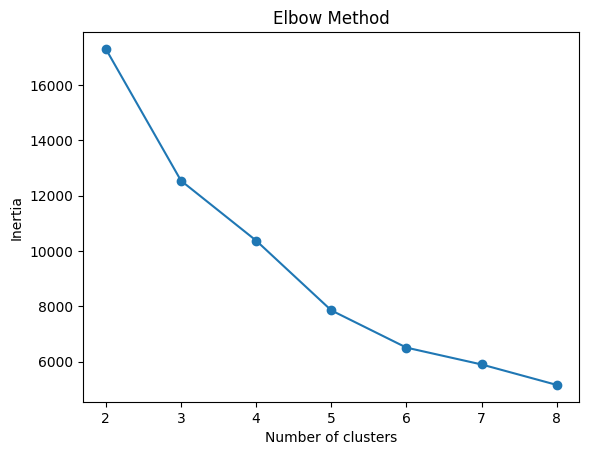

In [35]:
from sklearn.metrics import silhouette_score

for k in range(3, 9):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"{k}, score:{score:.4f}")

# Elbow method evaluation
inertias = []
for k in range(2, 9):
    kmeans_elbow = KMeans(n_clusters=k, random_state=42)
    kmeans_elbow.fit(X_scaled)
    inertias.append(kmeans_elbow.inertia_)

plt.plot(range(2, 9), inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

Silhouette score shows 4 clusters will give a good balance of cluster separation.

### Gausian Mixture Model Clustering

In [36]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=4,     
    covariance_type='full',
    reg_covar=1e-3,
    random_state=42)

rfm_data["Cluster_GMM"] = gmm.fit_predict(X_scaled)

print("-------------- Model Fit Summary: ---------------")
print(f"\tNumber of components: {gmm.get_params()['n_components']}")
print(f"\tConvergence achieved: {gmm.converged_}")
print("-------------------------------------------------")

-------------- Model Fit Summary: ---------------
	Number of components: 4
	Convergence achieved: True
-------------------------------------------------


#### Log-likelihood measures:
> “How probable is this customer under the learned distribution?”

In [37]:
risk_score = gmm.score_samples(X_scaled)

print(f"Risk score range: {risk_score.min():.4f} to {risk_score.max():.4f}")

Risk score range: -104.2830 to 0.7455


In [ ]:
def build_risk_profiles(df: pd.DataFrame, risk_score: np.ndarray):

    df["Cluster_GMM"] = gmm.predict(X_scaled)

    df["LogLikelihood"] = risk_score

    cluster_stats = df.groupby("Cluster_GMM")["LogLikelihood"].agg(["mean", "std"])

    means = df["Cluster_GMM"].map(cluster_stats["mean"])
    stds = df["Cluster_GMM"].map(cluster_stats["std"])
    stds_safe = stds.replace(0, 1)

    df["LL_norm"] = (df["LogLikelihood"] - means) / stds_safe


    conditions = [
        df["LL_norm"] < -1.5,
        df["LL_norm"] < -0.5
    ]

    choices = ["High Risk", "Medium Risk", "Low Risk"]

    df["RiskProfile"] = np.select(conditions, choices, default="Low Risk")

    print(df.RiskProfile.value_counts())
    df.drop(columns=["Cluster_GMM", "LogLikelihood", "LL_norm"], inplace=True)

    cluster_stats.to_csv("models/cluster_stats.csv")

    return df

In [39]:
# Only Risk scoring, no labelling for GMM
rfm_data = build_risk_profiles(rfm_data, risk_score)
rfm_data

RiskProfile
Low Risk       3448
Medium Risk     514
High Risk       361
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,Segment,RiskProfile
0,0,1,37.56,18356.8876,912.923130,VIP,Low Risk
2,12347,2,7.00,4310.0000,615.714286,Potential,Low Risk
3,12348,75,4.00,1797.2400,449.310000,At Risk,Medium Risk
4,12349,19,1.00,1757.5500,1682.641422,Potential,Medium Risk
5,12350,310,1.00,334.4000,334.400000,Churned,Low Risk
...,...,...,...,...,...,...,...
4367,18280,278,1.00,180.6000,180.600000,Churned,Low Risk
4368,18281,181,1.00,80.8200,80.820000,Churned,Low Risk
4369,18282,8,3.00,176.6000,58.866667,At Risk,Medium Risk
4370,18283,4,16.00,2094.8800,130.930000,Potential,Low Risk


In [40]:
print("Covariance matrices for GMM:")
print(gmm.covariances_)

Covariance matrices for GMM:
[[[ 8.57861950e-01 -9.35482541e-03 -1.04465612e-02 -2.44828608e-02]
  [-9.35482541e-03  1.57826622e-02  5.05219400e-03 -2.33714264e-02]
  [-1.04465612e-02  5.05219400e-03  1.78674660e-02  6.31480927e-02]
  [-2.44828608e-02 -2.33714264e-02  6.31480927e-02  4.12984886e-01]]

 [[ 5.21037009e-01 -9.93565093e-03 -2.64757559e-01 -2.50328248e-01]
  [-9.93565093e-03  3.43110677e-01  2.55725924e-01 -5.17445752e-01]
  [-2.64757559e-01  2.55725924e-01  1.09793170e+00  7.42000643e-01]
  [-2.50328248e-01 -5.17445752e-01  7.42000643e-01  3.38076309e+00]]

 [[ 6.09371933e-02 -2.08091315e-02 -1.79056979e-02  2.82572593e-03]
  [-2.08091315e-02  2.17903607e-01  1.62964492e-01 -3.85197126e-02]
  [-1.79056979e-02  1.62964492e-01  2.38480253e-01  1.15923618e-01]
  [ 2.82572593e-03 -3.85197126e-02  1.15923618e-01  2.18123771e-01]]

 [[ 2.39456813e-02 -8.45896201e-02 -5.62262394e-02  3.04736534e-02]
  [-8.45896201e-02  3.42487040e+00  4.28692821e+00 -1.33184139e-01]
  [-5.6226239

#### Evaluate GMM Clusters

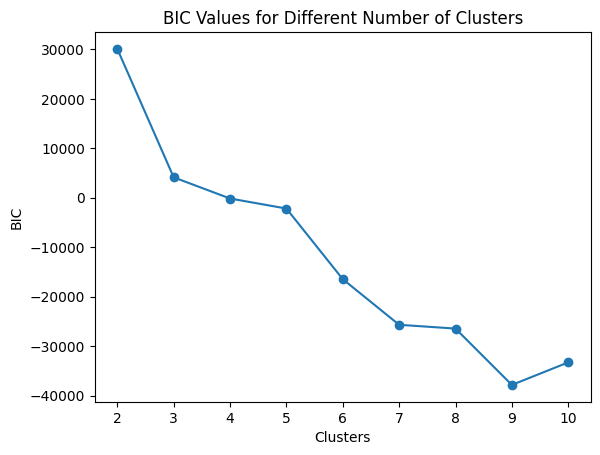

In [41]:
bic_scores = []
k_range = range(2, 11)

for k in k_range:
    gmm_2 = GaussianMixture(n_components=k, random_state=43, covariance_type='full')
    gmm_2.fit(X_scaled)
    bic_scores.append(gmm_2.bic(X_scaled))

import matplotlib.pyplot as plt
plt.plot(k_range, bic_scores, marker='o')
plt.xlabel("Clusters")
plt.ylabel("BIC")
plt.title("BIC Values for Different Number of Clusters")
plt.show()

In [42]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    gmm_ss = GaussianMixture(n_components=k, random_state=43, covariance_type='full')
    gmm_labels = gmm_ss.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, gmm_labels)
    print(f"{k}, score:{score:.4f}")

2, score:0.3884
3, score:0.1080
4, score:0.0532
5, score:0.0780
6, score:0.0543
7, score:0.0353
8, score:0.0373
9, score:0.0177
10, score:0.0225


Kmeans and GMM have similar silhoutte score for 4 clusters, but GMM can capture more complex cluster shapes and may provide better segmentation in cases where clusters are not well-separated.

In our case, we will use Kmeans for core segmentation, and GMM can be used for risk profiling to identify customers who are at risk of churning. 

#### Mapping Risk Profiles to Business Segments

In [43]:
seg_risk_matrix_pct = pd.crosstab(rfm_data["Segment"], rfm_data["RiskProfile"],  normalize='index') * 100
print(seg_risk_matrix_pct.round(2))

RiskProfile  High Risk  Low Risk  Medium Risk
Segment                                      
At Risk           7.47     81.10        11.43
Churned          10.82     77.10        12.09
Potential         6.72     83.84         9.44
VIP              16.00     47.00        37.00


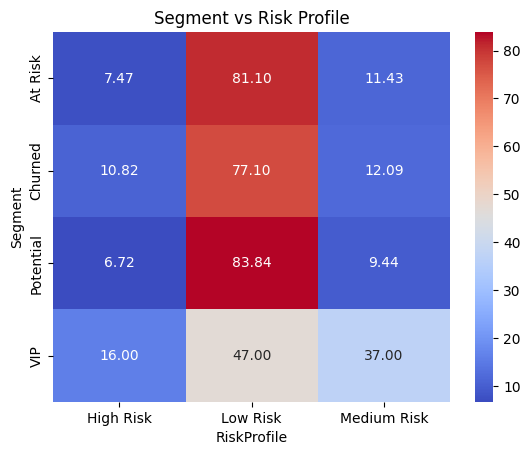

In [44]:
sb.heatmap(seg_risk_matrix_pct, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Segment vs Risk Profile")
plt.show()

🟢 VIP + Low Risk:

Stable high-value customers
Consistent behavior
👉 Action:
Loyalty rewards
Premium upsell

🟡 VIP + Medium Risk:

Slight behavioral drift
Early warning
👉 Action:
Personalized nudges
Engagement campaigns

🔴 VIP + High Risk:
🚨 MOST IMPORTANT SEGMENT

High value but deviating behavior
👉 Action:
Immediate intervention
High-touch retention (calls, exclusive offers)
🚀 Potential Segment

<hr>

🟢 Potential + Low Risk:

Stable mid-value customers
Growth opportunity
👉 Action:
Cross-sell / bundles

🟡 Potential + Medium Risk:

Inconsistent engagement
👉 Action:
Incentives to increase frequency

🔴 Potential + High Risk:

Dropping before converting to high value
👉 Action:
Strong nudges
Personalized recommendations


<hr>
🟢 At Risk + Low Risk:

Temporarily inactive but stable
👉 Action:
Light reminders

🟡 At Risk + Medium Risk:

Clear decline
👉 Action:
Win-back campaigns

🔴 At Risk + High Risk:

🚨 Likely churn soon
👉 Action:
Aggressive retention offers


<hr>
🟢 Churned + Low Risk:

Stable inactivity
👉 Action:
Low priority reactivation

🟡 Churned + Medium Risk:

Some residual engagement
👉 Action:
Targeted reactivation

🔴 Churned + High Risk:

Completely disengaged / erratic
👉 Action:
Suppress or last-attempt campaigns

## Model Building :- Predictive Classifier

In [45]:
rfm_data

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,Segment,RiskProfile
0,0,1,37.56,18356.8876,912.923130,VIP,Low Risk
2,12347,2,7.00,4310.0000,615.714286,Potential,Low Risk
3,12348,75,4.00,1797.2400,449.310000,At Risk,Medium Risk
4,12349,19,1.00,1757.5500,1682.641422,Potential,Medium Risk
5,12350,310,1.00,334.4000,334.400000,Churned,Low Risk
...,...,...,...,...,...,...,...
4367,18280,278,1.00,180.6000,180.600000,Churned,Low Risk
4368,18281,181,1.00,80.8200,80.820000,Churned,Low Risk
4369,18282,8,3.00,176.6000,58.866667,At Risk,Medium Risk
4370,18283,4,16.00,2094.8800,130.930000,Potential,Low Risk


New Feature for Classifier: "Segment | Risk" which combines the segment and risk profile into a single feature for classification.

In [46]:
rfm_data["Segment | Risk"] = rfm_data["Segment"] + " --- " + rfm_data["RiskProfile"]
rfm_data.drop(columns=["RiskProfile", "Segment"], inplace=True)

In [47]:
rfm_data

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,Segment | Risk
0,0,1,37.56,18356.8876,912.923130,VIP --- Low Risk
2,12347,2,7.00,4310.0000,615.714286,Potential --- Low Risk
3,12348,75,4.00,1797.2400,449.310000,At Risk --- Medium Risk
4,12349,19,1.00,1757.5500,1682.641422,Potential --- Medium Risk
5,12350,310,1.00,334.4000,334.400000,Churned --- Low Risk
...,...,...,...,...,...,...
4367,18280,278,1.00,180.6000,180.600000,Churned --- Low Risk
4368,18281,181,1.00,80.8200,80.820000,Churned --- Low Risk
4369,18282,8,3.00,176.6000,58.866667,At Risk --- Medium Risk
4370,18283,4,16.00,2094.8800,130.930000,Potential --- Low Risk


### Train Test Split

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC 

In [49]:
X = rfm_data.drop(columns=["CustomerID", "Segment | Risk"])
y = rfm_data["Segment | Risk"]

### Model Fitting and Evaluation

In [ ]:
from sklearn.model_selection import StratifiedKFold

def validate_and_fit_model(model, X, y, cv=5, random_state=38, name="Model"):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    scores = []
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        model.fit(X_train, y_train)
        score = model.score(X_test, y_test)
        scores.append(score)

    avg_score = sum(scores) / len(scores)
    print(f"{name} cross-validation completed. \nAverage CV Accuracy: {avg_score:.4f}")
    print("-" * 60)

    # Fit on the full dataset
    model.fit(X, y)
    return model, X_test, y_test

In [51]:
rfc_fit, rfc_xtest, rfc_ytest = validate_and_fit_model(RandomForestClassifier(
    random_state=42,
    max_depth=5,
    max_features='sqrt'
    ), X, y, name="Random Forest")

gbc_fit , gbc_xtest, gbc_ytest = validate_and_fit_model(GradientBoostingClassifier(
    random_state=42,
    max_depth=3,
    n_estimators=120,
    learning_rate=0.05,
    ), X, y, name="Gradient Boost")

svc_fit, svc_xtest, svc_ytest = validate_and_fit_model(SVC(random_state=42), X, y, name="SVM")

Random Forest cross-validation completed. 
Average CV Accuracy: 0.8182
------------------------------------------------------------
Gradient Boost cross-validation completed. 
Average CV Accuracy: 0.8947
------------------------------------------------------------
SVM cross-validation completed. 
Average CV Accuracy: 0.7728
------------------------------------------------------------


In [52]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {len(Xtrain)}")
print(f"Test set size: {len(Xtest)}")

gbc_model = GradientBoostingClassifier(
    random_state=42,
    max_depth=3,
    n_estimators=120,
    learning_rate=0.05,
)

gbc_model = gbc_model.fit(Xtrain, ytrain)

Training set size: 3458
Test set size: 865


We will use Gradient Boosting as our default classifier as this model returned better accuracy (95%). 

In [53]:
y_pred = gbc_model.predict(Xtest)
y_pred.shape

(865,)

In [54]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

                           precision    recall  f1-score   support

    At Risk --- High Risk       0.84      0.54      0.66        39
     At Risk --- Low Risk       0.91      0.97      0.94       417
  At Risk --- Medium Risk       0.70      0.51      0.59        59
    Churned --- High Risk       0.77      0.91      0.83        22
     Churned --- Low Risk       0.97      0.97      0.97       158
  Churned --- Medium Risk       0.81      0.68      0.74        25
  Potential --- High Risk       1.00      0.38      0.55         8
   Potential --- Low Risk       0.93      0.94      0.93       105
Potential --- Medium Risk       0.69      0.75      0.72        12
        VIP --- High Risk       1.00      1.00      1.00         3
         VIP --- Low Risk       0.64      0.90      0.75        10
      VIP --- Medium Risk       0.83      0.71      0.77         7

                 accuracy                           0.89       865
                macro avg       0.84      0.77      0.79    

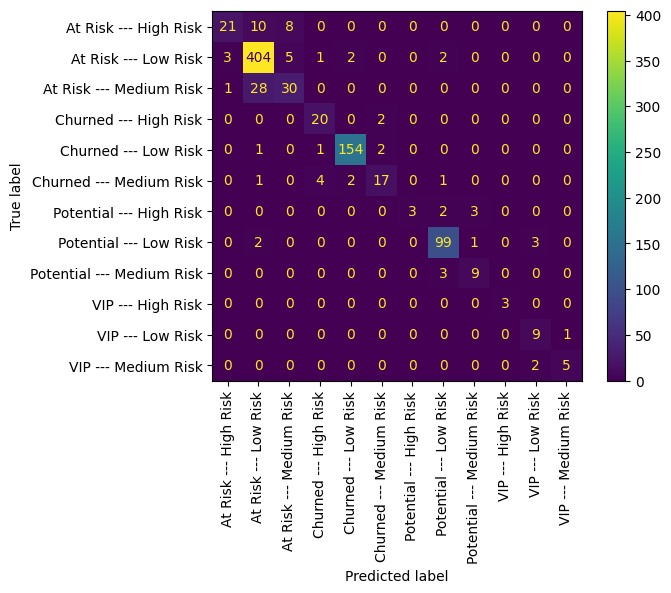

In [55]:
print(classification_report(ytest, y_pred, zero_division=0))
ConfusionMatrixDisplay.from_predictions(ytest, y_pred, xticks_rotation=90)

In [56]:
gbc_model.predict([[1000, 7, 53, 53/7]])

p:\Boston Insitute of Analytics\Capstone Project\Ecom-Customer-Segregation\.venv-cp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


array(['Churned --- High Risk'], dtype=object)

In [57]:
import joblib as jl

jl.dump(kmc_model, "models/KmeansCluster.pkl")
jl.dump(gmm, "models/GMM_RiskProfile.pkl")
jl.dump(gbc_model, "models/GB_Classifier.pkl")
jl.dump(pt, "models/PowerTransformer.pkl")
jl.dump(scaler, "models/RobustScaler.pkl")
jl.dump(caps, "models/Caps.pkl")

['models/Caps.pkl']